<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 11

## **Graph Generation Models**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Objective

To understand the structural properties of different graph models by generating and analyzing networks using the **NetworkX** library.

**Tasks:**
1. Generate an **Erdős–Rényi** random graph (n=500, p=0.05)
2. Generate a **Watts–Strogatz** small-world graph (n=500, k=10, β=0.1)
3. Generate a **Barabási–Albert** scale-free graph (n=500, m=5)
4. Visualize all three graphs using NetworkX
5. Compute and compare structural metrics in a table
6. Plot degree distributions (including log-log for BA model)
7. Save all three graphs in Gephi-compatible GEXF format
8. Discuss why the BA model is more realistic for real-world networks

**Required Libraries:** `networkx`, `matplotlib`, `numpy`, `collections`

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

print("Imports successful")

Imports successful


## Task 1 – Erdős–Rényi Random Graph

In the ER model, each pair of n nodes is connected with probability p, independently. It produces a binomial degree distribution that approximates a Poisson distribution for large n.

In [2]:
G_er = nx.erdos_renyi_graph(n=500, p=0.05, seed=42)

print(f"Erdős–Rényi Graph")
print(f"  Nodes : {G_er.number_of_nodes()}")
print(f"  Edges : {G_er.number_of_edges()}")

Erdős–Rényi Graph
  Nodes : 500
  Edges : 6162


## Task 2 – Watts–Strogatz Small-World Graph

The WS model starts with a regular ring lattice and rewires each edge with probability β. It captures the high clustering and short average path length characteristic of real social networks.

In [3]:
G_ws = nx.watts_strogatz_graph(n=500, k=10, p=0.1, seed=42)

print(f"Watts–Strogatz Graph")
print(f"  Nodes : {G_ws.number_of_nodes()}")
print(f"  Edges : {G_ws.number_of_edges()}")

Watts–Strogatz Graph
  Nodes : 500
  Edges : 2500


## Task 3 – Barabási–Albert Scale-Free Graph

The BA model builds the network incrementally. At each step a new node joins and attaches m edges to existing nodes with probability proportional to their current degree (preferential attachment), yielding a power-law degree distribution.

In [4]:
G_ba = nx.barabasi_albert_graph(n=500, m=5, seed=42)

print(f"Barabási–Albert Graph")
print(f"  Nodes : {G_ba.number_of_nodes()}")
print(f"  Edges : {G_ba.number_of_edges()}")

Barabási–Albert Graph
  Nodes : 500
  Edges : 2475


## Task 4 – Visualizations

Each graph is drawn with a spring layout using a small node size (10) to handle 500 nodes.

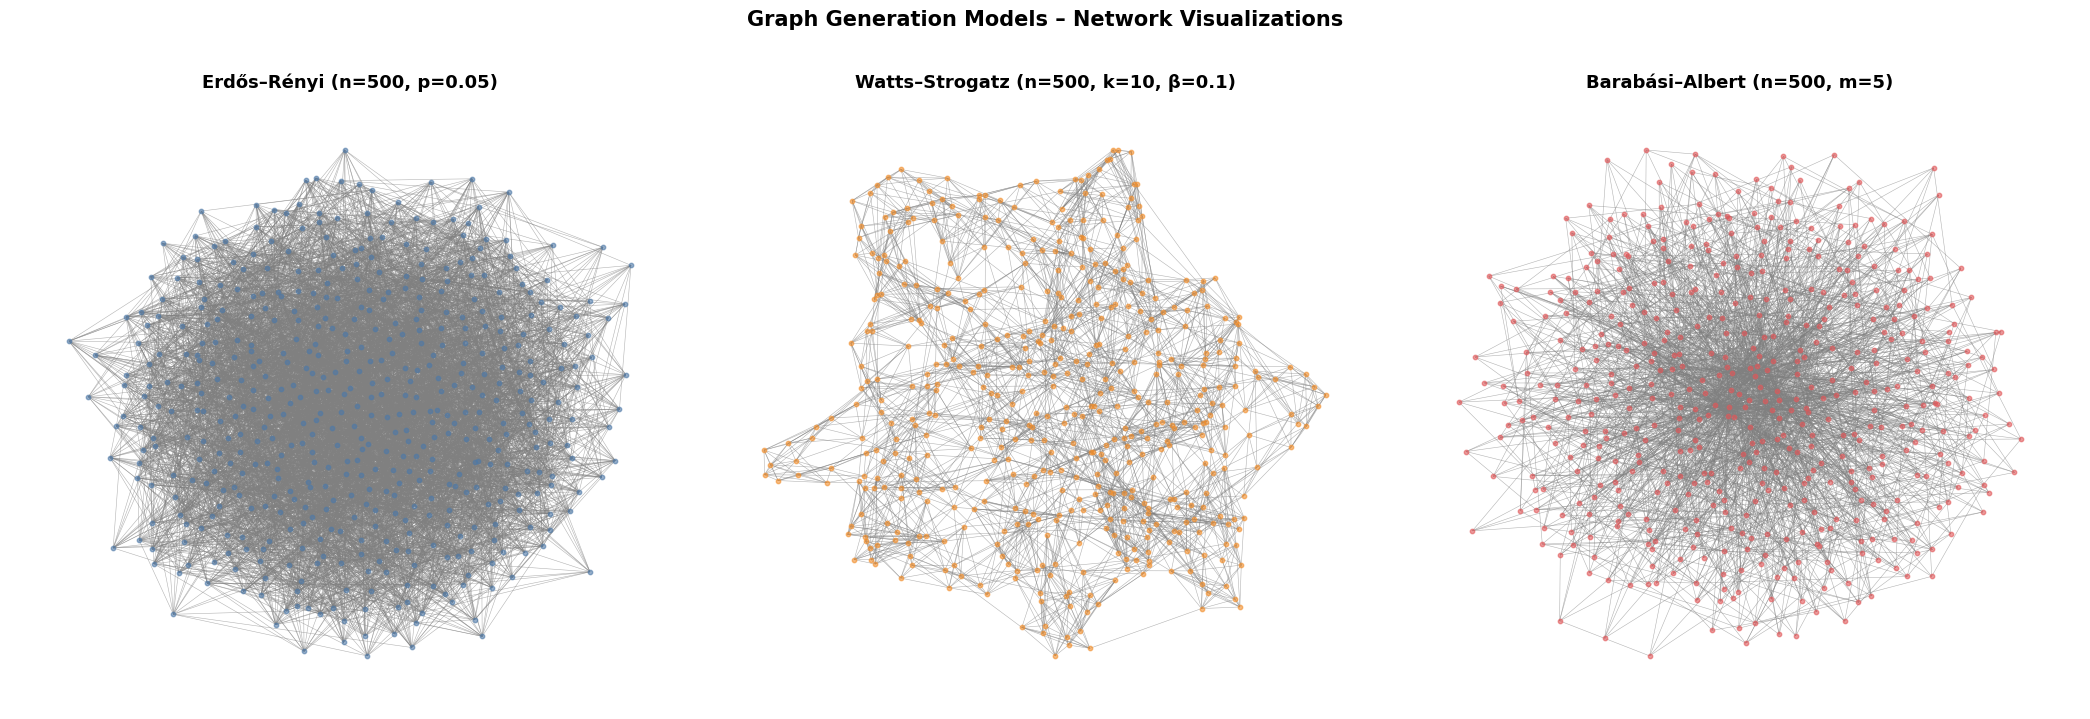

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

graphs = [
    (G_er, "Erdős–Rényi (n=500, p=0.05)", "#4E79A7"),
    (G_ws, "Watts–Strogatz (n=500, k=10, β=0.1)", "#F28E2B"),
    (G_ba, "Barabási–Albert (n=500, m=5)", "#E15759"),
]

for ax, (G, title, color) in zip(axes, graphs):
    pos = nx.spring_layout(G, seed=42, k=0.3)
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_size=10, node_color=color,
        edge_color="gray", alpha=0.6,
        with_labels=False, width=0.4
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Graph Generation Models – Network Visualizations",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Task 5 – Comparative Metrics Table

| Metric | Erdős–Rényi | Watts–Strogatz | Barabási–Albert |
|--------|-------------|----------------|-----------------|
| Average Degree | 24.64 | 10 | 9.9 |
| Average Clustering Coefficient | 0.0502 | 0.5034 | 0.0790 |
| Average Shortest Path Length | 2.2311 | 3.9897 | 2.7308 |
| Diameter | 3 | 7 | 4 |

## Task 6 – Degree Distribution Plots

Three histograms show degree frequency for each model. The BA model is additionally shown on a log-log scale to reveal its power-law behaviour.

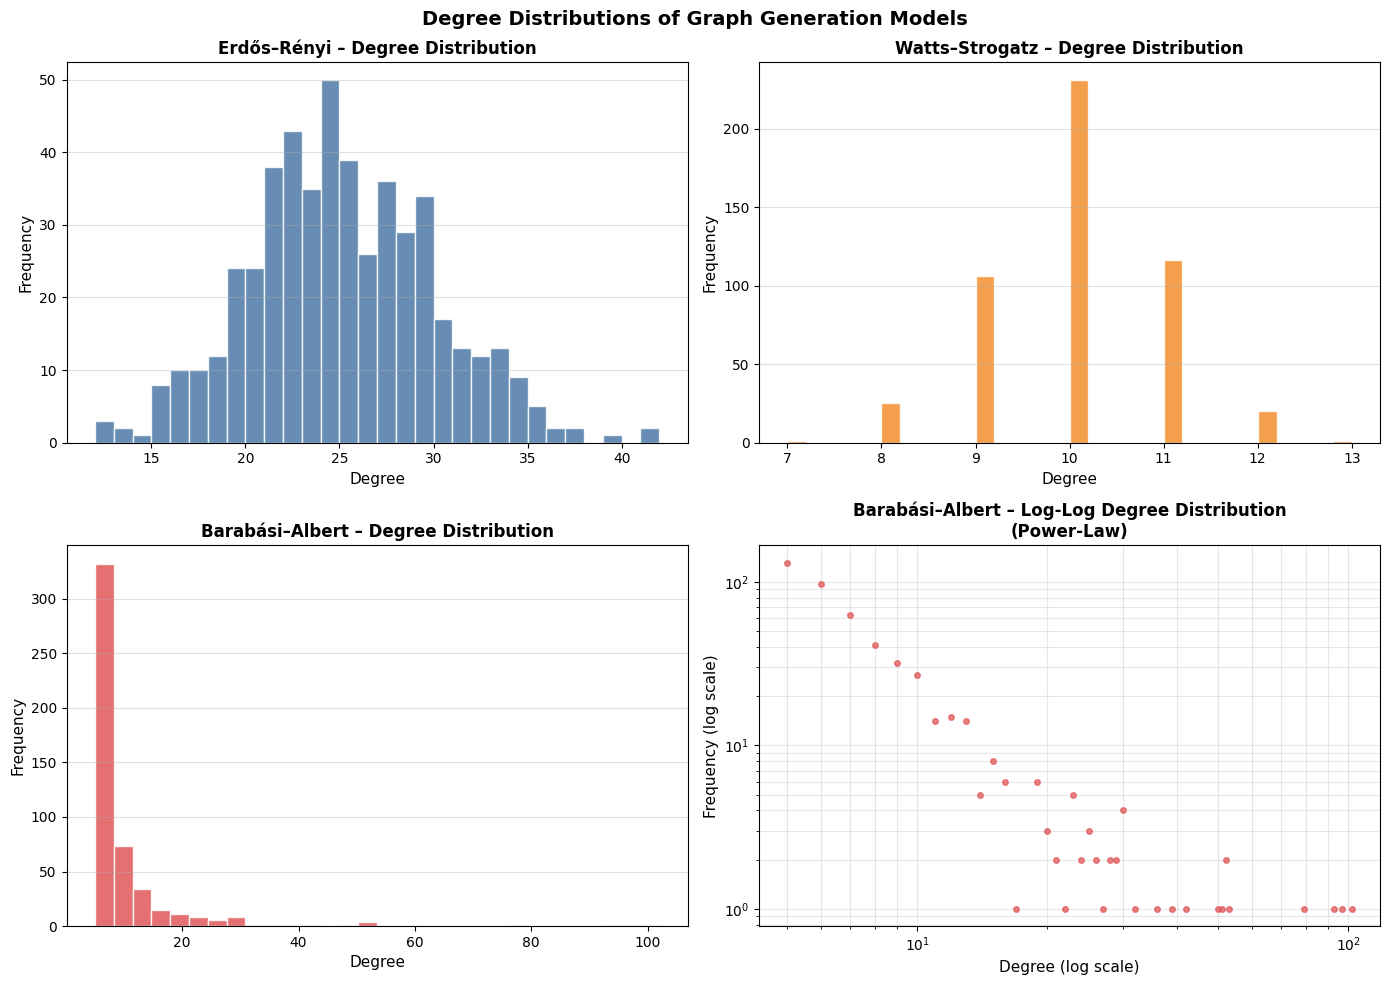

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

graph_info = [
    (G_er, "Erdős–Rényi",     "#4E79A7", axes[0, 0]),
    (G_ws, "Watts–Strogatz",  "#F28E2B", axes[0, 1]),
    (G_ba, "Barabási–Albert", "#E15759", axes[1, 0]),
]

for G, name, color, ax in graph_info:
    degrees = [d for _, d in G.degree()]
    ax.hist(degrees, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel("Degree", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title(f"{name} – Degree Distribution", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.4)

ax_ll = axes[1, 1]
ba_degrees = [d for _, d in G_ba.degree()]
degree_count = Counter(ba_degrees)
x_vals = sorted(degree_count.keys())
y_vals = [degree_count[k] for k in x_vals]

ax_ll.plot(x_vals, y_vals, "o", color="#E15759", markersize=4, alpha=0.75)
ax_ll.set_xscale("log")
ax_ll.set_yscale("log")
ax_ll.set_xlabel("Degree (log scale)", fontsize=11)
ax_ll.set_ylabel("Frequency (log scale)", fontsize=11)
ax_ll.set_title("Barabási–Albert – Log-Log Degree Distribution\n(Power-Law)",
                fontsize=12, fontweight="bold")
ax_ll.grid(True, which="both", alpha=0.3)

plt.suptitle("Degree Distributions of Graph Generation Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Task 7 – Save Graphs in Gephi-Compatible Format (GEXF)

All three graphs are exported as `.gexf` files which can be opened directly in Gephi for aesthetic visualisation.

In [8]:
nx.write_gexf(G_er, "erdos_renyi_graph.gexf")
nx.write_gexf(G_ws, "watts_strogatz_graph.gexf")
nx.write_gexf(G_ba, "barabasi_albert_graph.gexf")

print("Saved:")
print("  erdos_renyi_graph.gexf")
print("  watts_strogatz_graph.gexf")
print("  barabasi_albert_graph.gexf")

Saved:
  erdos_renyi_graph.gexf
  watts_strogatz_graph.gexf
  barabasi_albert_graph.gexf


## Task 8: Gephi Visualizations:

### 1. Erdős Renyi Graph

<img src="Graphs/erdos_renyi_graph.svg" width="800"/>

### 2. Watts Strogatz Graph

<img src="Graphs/watts_strogatz_graph.svg" width="800"/>

### 3. Barabási Albert Graph

<img src="Graphs/barabasi_albert_graph.svg" width="800"/>

## Discussion – Why is the Barabási–Albert Model More Realistic?

The **Barabási–Albert (BA) model** is generally considered more realistic for social networks and the internet compared to the **Erdős–Rényi (ER) model** because of its *preferential attachment* mechanism. In the real world, new nodes (people, websites) are far more likely to connect to already popular nodes—a phenomenon captured by the phrase *"rich get richer"*. This produces a **power-law degree distribution** where a small number of hubs have a very high degree, while the majority of nodes have a low degree. This "heavy-tail" behaviour is observed empirically across the internet's router graph, citation networks, and social platforms.

By contrast, the ER model assigns edges at random with a fixed probability, resulting in a bell-shaped (Poisson) degree distribution. Real networks almost never exhibit such uniformity; instead, their degree distributions are right-skewed with rare, highly connected hubs. The BA model replicates this skew naturally through its growth rule, making it a far better approximation of how real complex networks evolve over time.